In [1]:
# Task 1
# DATA EXPLORATION AND PREPROCESSING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/adult_with_headers.csv")

#1. Data Exploration and Preprocessing:

•	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).


•	Handle missing values as per the best practices (imputation, removal, etc.).

•	Apply scaling techniques to numerical features:

•	Standard Scaling

•	Min-Max Scaling

•	Discuss the scenarios where each scaling technique is preferred and why.


In [2]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education_num,int64
marital_status,object
occupation,object
relationship,object
race,object
sex,object


In [6]:
df .isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
for i in df.isna().sum():
  print((i/len(df))*100)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [8]:
df.duplicated().sum()
df[df.duplicated()]
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

<Axes: >

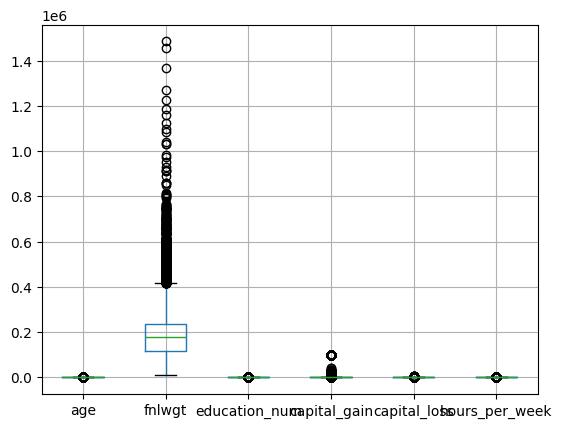

In [9]:
df.boxplot() #to show that there are outlier present in data

<Axes: >

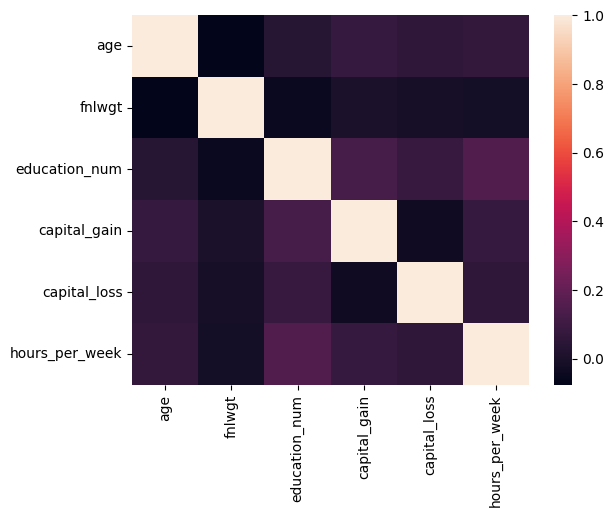

In [10]:
# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=np.number)

# Calculate and display the correlation matrix heatmap
sns.heatmap(numerical_df.corr())

<Axes: >

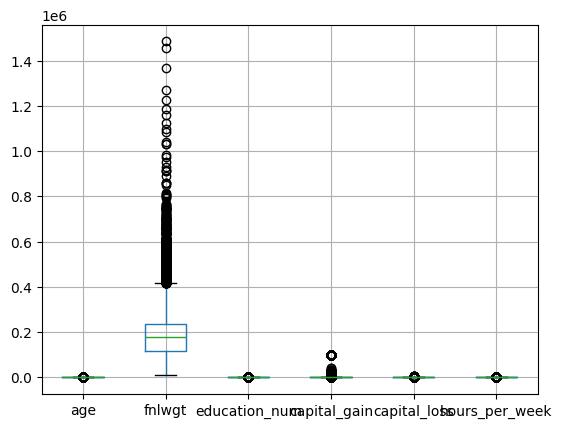

In [11]:
df. boxplot()

<Axes: >

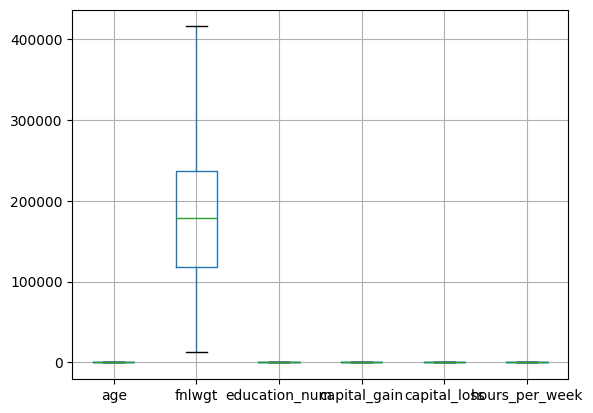

In [12]:
def outlier_treatment(data,columns):
  q1=data[columns].quantile(0.25)
  iqr=data[columns].quantile(0.75)-q1
  lower_limit=q1-1.5*iqr
  upper_limit=data[columns].quantile(0.75)+1.5*iqr

  data[columns]=np.where(data[columns]>upper_limit,upper_limit,data[columns])
  data[columns]=np.where(data[columns]<lower_limit,lower_limit,data[columns])

  return data

  #apply to all numerical columns
numerical_cols= df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  df=outlier_treatment(df,col)

#check after capping
df.boxplot()


In [13]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [14]:
df.duplicated().sum()

np.int64(27)

In [15]:
# Standing Scaling

from sklearn.preprocessing import StandardScaler

#selecting numerical columns

numerical_cols=df.select_dtypes(include=['int64','float64']).columns
#appling standard scaling

scaler = StandardScaler()
df_standard_scale =df.copy()
df_standard_scale[numerical_cols]=scaler.fit_transform(df[numerical_cols])

#view results
df_standard_scale.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.032472,State-gov,-1.149209,Bachelors,1.168918,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
1,0.844002,Self-emp-not-inc,-1.088284,Bachelors,1.168918,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,-1.406640,United-States,<=50K
2,-0.041304,Private,0.303007,HS-grad,-0.457496,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
3,1.065329,Private,0.503550,11th,-1.270703,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,-0.194472,United-States,<=50K
4,-0.779058,Private,1.593665,Bachelors,1.168918,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,-0.194472,Cuba,<=50K


In [16]:
# Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

#selecting numerical columns

numerical_cols=df.select_dtypes(include=['int64','float64']).columns
#appling standard scaling

scaler = MinMaxScaler()
df_min_max_scale =df.copy()
df_min_max_scale[numerical_cols]=scaler.fit_transform(df[numerical_cols])

#view results
df_min_max_scale.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.360656,State-gov,0.161680,Bachelors,0.739130,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,0.375,United-States,<=50K
1,0.540984,Self-emp-not-inc,0.176044,Bachelors,0.739130,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,0.000,United-States,<=50K
2,0.344262,Private,0.504046,HS-grad,0.391304,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,0.375,United-States,<=50K
3,0.590164,Private,0.551325,11th,0.217391,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,0.375,United-States,<=50K
4,0.180328,Private,0.808324,Bachelors,0.739130,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,0.375,Cuba,<=50K


#2. Encoding Techniques:

•	Apply One-Hot Encoding to categorical variables with less than 5 categories.

•	Use Label Encoding for categorical variables with more than 5 categories.

•	Discuss the pros and cons of One-Hot Encoding and Label Encoding.


### Identifying Categorical Columns and Applying Encoding Techniques

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Make a copy of the original DataFrame to apply encoding
df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include='object').columns

one_hot_cols = []
label_cols = []

for col in categorical_cols:
    if df_encoded[col].nunique() < 5:
        one_hot_cols.append(col)
    else:
        label_cols.append(col)

print(f"Columns for One-Hot Encoding: {one_hot_cols}")
print(f"Columns for Label Encoding: {label_cols}")

Columns for One-Hot Encoding: ['sex', 'income']
Columns for Label Encoding: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


#### One-Hot Encoding for columns with less than 5 unique categories

In [20]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)
display(df_encoded.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,0.0,0.0,40.0,United-States,True,False
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,32.5,United-States,True,False
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,40.0,United-States,True,False
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,40.0,United-States,True,False
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,40.0,Cuba,False,False


#### Label Encoding for columns with 5 or more unique categories

In [21]:
# Apply Label Encoding
label_encoder = LabelEncoder()
for col in label_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
display(df_encoded.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39.0,7,77516.0,9,13.0,4,1,1,4,0.0,0.0,40.0,39,True,False
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,0.0,32.5,39,True,False
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,0.0,40.0,39,True,False
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,0.0,40.0,39,True,False
4,28.0,4,338409.0,9,13.0,2,10,5,2,0.0,0.0,40.0,5,False,False


### Discussion on One-Hot Encoding vs. Label Encoding

#### One-Hot Encoding
**Pros:**
*   **Avoids ordinality assumption:** It creates new binary features for each category, ensuring that the model does not assume an ordinal relationship between categories. This is crucial when no such inherent order exists (e.g., 'Red', 'Green', 'Blue').
*   **Suitable for tree-based models:** Many machine learning algorithms, especially those not distance-based, work well with one-hot encoded features.

**Cons:**
*   **High dimensionality:** For categorical variables with a large number of unique categories, one-hot encoding can significantly increase the number of features, leading to the "curse of dimensionality". This can slow down training and potentially lead to overfitting.
*   **Increased sparsity:** The resulting DataFrame can become very sparse (many zero values), which might not be efficient for all algorithms.

#### Label Encoding
**Pros:**
*   **Reduced dimensionality:** It transforms each category into a single numerical value, keeping the number of features the same. This is memory-efficient and faster for models that are sensitive to high dimensionality.
*   **Simple to implement:** It's straightforward to apply.

**Cons:**
*   **Implies ordinality:** The main drawback is that it assigns an arbitrary numerical order to categories (e.g., 0, 1, 2, 3...). This can mislead models into assuming an ordinal relationship where none exists. For instance, if 'Red' is encoded as 0 and 'Blue' as 1, the model might incorrectly infer that 'Blue' is 'greater' than 'Red'. This is particularly problematic for linear models or neural networks.
*   **Not suitable for nominal data:** Due to the ordinality assumption, it's generally not recommended for nominal categorical features (categories without any intrinsic order).

#### When to Use Each:
*   **One-Hot Encoding:** Preferred for nominal categorical variables (no inherent order) and when the number of unique categories is relatively small. It's generally safer to use unless dimensionality becomes a significant issue.
*   **Label Encoding:** Best used for ordinal categorical variables (where there is a clear, meaningful order, e.g., 'low', 'medium', 'high') or when the number of categories is very large, and the model being used is robust to the induced ordinality (e.g., tree-based models can sometimes handle this without explicit ordinal information if the splits align correctly).

#3. Feature Engineering:

•	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

•	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.


In [ ]:
# Create 'Education_Age_Interaction'
df_encoded['Education_Age_Interaction'] = df_encoded['education_num'] * df_encoded['age']

# Create 'Work_Hours_Category'
def categorize_hours(hours):
    if hours < 30:
        return 'Part-time'
    elif hours <= 40:
        return 'Full-time'
    else:
        return 'Overtime'

df_encoded['Work_Hours_Category'] = df_encoded['hours_per_week'].apply(categorize_hours)

# Display the new features and the head of the DataFrame
display(df_encoded[['age', 'education_num', 'Education_Age_Interaction', 'hours_per_week', 'Work_Hours_Category']].head())

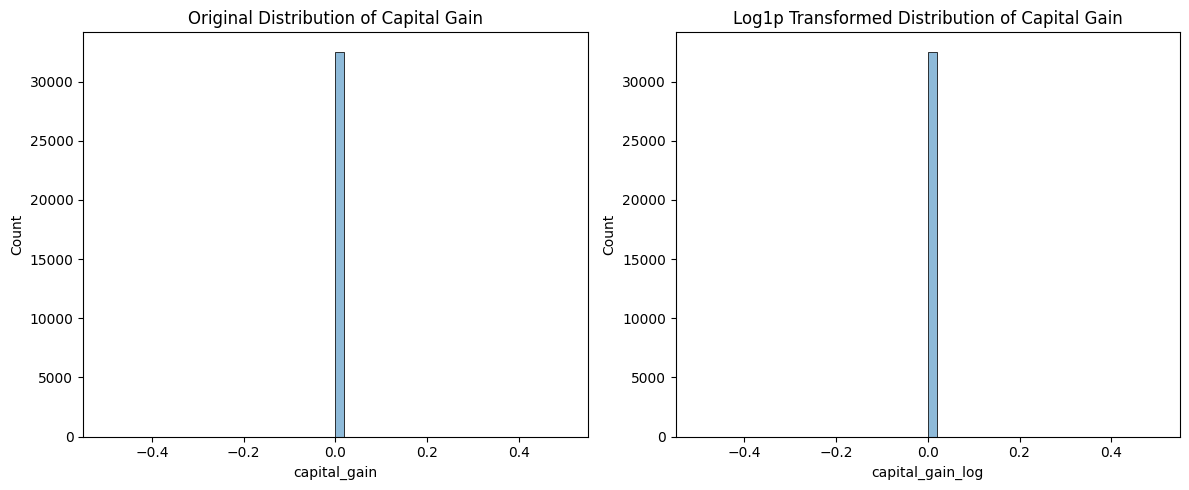

,capital_gain,capital_gain_log
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize original distribution of capital_gain
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_encoded['capital_gain'], bins=50, kde=True)
plt.title('Original Distribution of Capital Gain')

# Apply log1p transformation to capital_gain
df_encoded['capital_gain_log'] = np.log1p(df_encoded['capital_gain'])

# Visualize transformed distribution of capital_gain
plt.subplot(1, 2, 2)
sns.histplot(df_encoded['capital_gain_log'], bins=50, kde=True)
plt.title('Log1p Transformed Distribution of Capital Gain')
plt.tight_layout()
plt.show()

display(df_encoded[['capital_gain', 'capital_gain_log']].head())

#4. Feature Selection:

•	Use the Isolation Forest algorithm to identify and remove outliers. Discuss how outliers can affect model performance.

•	Apply the PPS (Predictive Power Score) to find and discuss the relationships between features. Compare its findings with the correlation matrix.


In [23]:
from sklearn.ensemble import IsolationForest

# Make a copy of the encoded DataFrame for outlier treatment
df_no_outliers = df_encoded.copy()

# Select only numerical features for Isolation Forest
# 'Work_Hours_Category' is categorical, so we should exclude it for now or encode it numerically if needed
numerical_features = df_no_outliers.select_dtypes(include=np.number).columns.tolist()

# Initialize and train Isolation Forest
# contamination: the proportion of outliers in the data set. Here, estimating automatically.
iso_forest = IsolationForest(random_state=42, contamination='auto')

# Fit the model and predict outliers (1 for inliers, -1 for outliers)
df_no_outliers['outlier_score'] = iso_forest.fit_predict(df_no_outliers[numerical_features])

# Filter out the outliers
df_no_outliers = df_no_outliers[df_no_outliers['outlier_score'] == 1].drop(columns=['outlier_score'])

print(f"Original DataFrame shape: {df_encoded.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")
display(df_no_outliers.head())

Original DataFrame shape: (32537, 16)
DataFrame shape after outlier removal: (24754, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K,capital_gain_log
0,39.0,7,77516.0,9,13.0,4,1,1,4,0.0,0.0,40.0,39,True,False,0.0
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,0.0,32.5,39,True,False,0.0
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,0.0,40.0,39,True,False,0.0
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,0.0,40.0,39,True,False,0.0
5,37.0,4,284582.0,12,14.0,2,4,5,4,0.0,0.0,40.0,39,False,False,0.0


  Preparing metadata (setup.py) ... done
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13180 sha256=ac77e03b7001ef9e3026a323a243a92d8dae0d7b88f91de39640ff1f3296d9d3
  Stored in directory: /root/.cache/pip/wheels/84/0d/d6/ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore


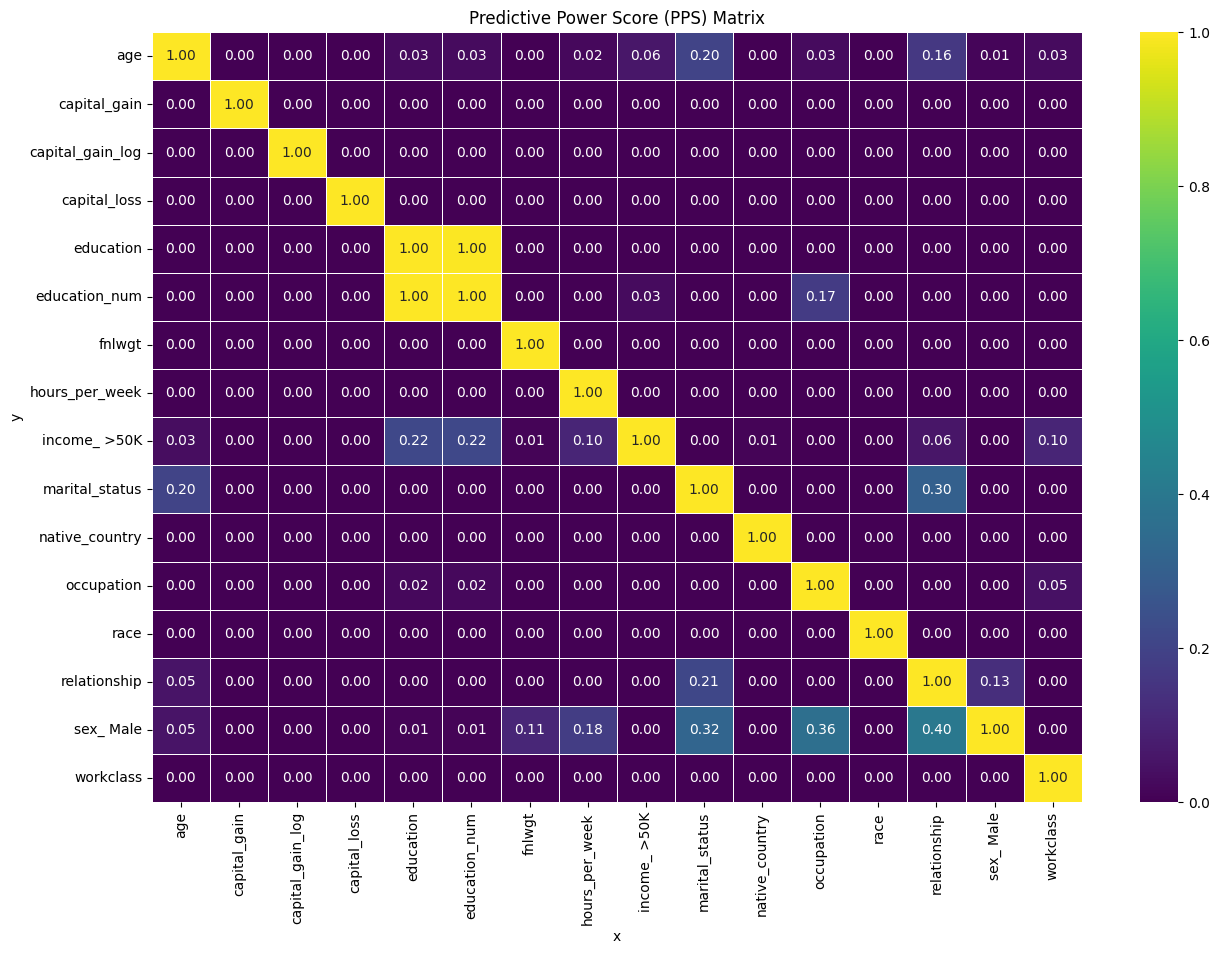


Top PPS scores (predictor -> target):


,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.0,None
17,workclass,workclass,1.0,predict_itself,True,None,0.0000,1.0,None
51,education,education,1.0,predict_itself,True,None,0.0000,1.0,None
34,fnlwgt,fnlwgt,1.0,predict_itself,True,None,0.0000,1.0,None
52,education,education_num,1.0,regression,True,mean absolute error,1.5982,0.0,DecisionTreeRegressor()
119,relationship,relationship,1.0,predict_itself,True,None,0.0000,1.0,None
85,marital_status,marital_status,1.0,predict_itself,True,None,0.0000,1.0,None
68,education_num,education_num,1.0,predict_itself,True,None,0.0000,1.0,None
102,occupation,occupation,1.0,predict_itself,True,None,0.0000,1.0,None
221,sex_ Male,sex_ Male,1.0,predict_itself,True,None,0.0000,1.0,None


In [24]:
# Install the ppscore library if not already installed
!pip install ppscore

import ppscore as pps

# Calculate the PPS matrix
# We will calculate PPS for all columns, using each column as a potential predictor for every other column.
pps_matrix = pps.matrix(df_no_outliers)

# Filter for score column and pivot to get a square matrix for heatmap visualization
pps_pivot = pps_matrix.pivot(columns='x', index='y', values='ppscore')

# Visualize the PPS matrix
plt.figure(figsize=(15, 10))
sns.heatmap(pps_pivot, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Predictive Power Score (PPS) Matrix')
plt.show()

# Display the top PPS scores for understanding strong predictive relationships
print("\nTop PPS scores (predictor -> target):")
display(pps_matrix.sort_values(by='ppscore', ascending=False).head(10))